Launching server at http://localhost:58634


FastListTemplate
    [js_area] HTML(None, height=0, margin=0, sizing_mode='fixed', width=0)
    [actions] TemplateActions()
    [browser_info] BrowserInfo()
    [busy_indicator] LoadingSpinner(height=20, width=20)
    [main-1352256949392] Row(sizing_mode='stretch_width')
        [0] Markdown(str, sizing_mode='stretch_width')
        [1] Markdown(str, sizing_mode='stretch_width')
        [2] Markdown(str, sizing_mode='stretch_width')
        [3] Markdown(str, sizing_mode='stretch_width')
    [main-1352308181264] RadioButtonGroup(options=['📊 Overview', ...], sizing_mode='stretch_width', value='📊 Overview')
    [main-1352308182224] ParamFunction(function, _pane=Matplotlib, defer_load=False, sizing_mode='stretch_width')
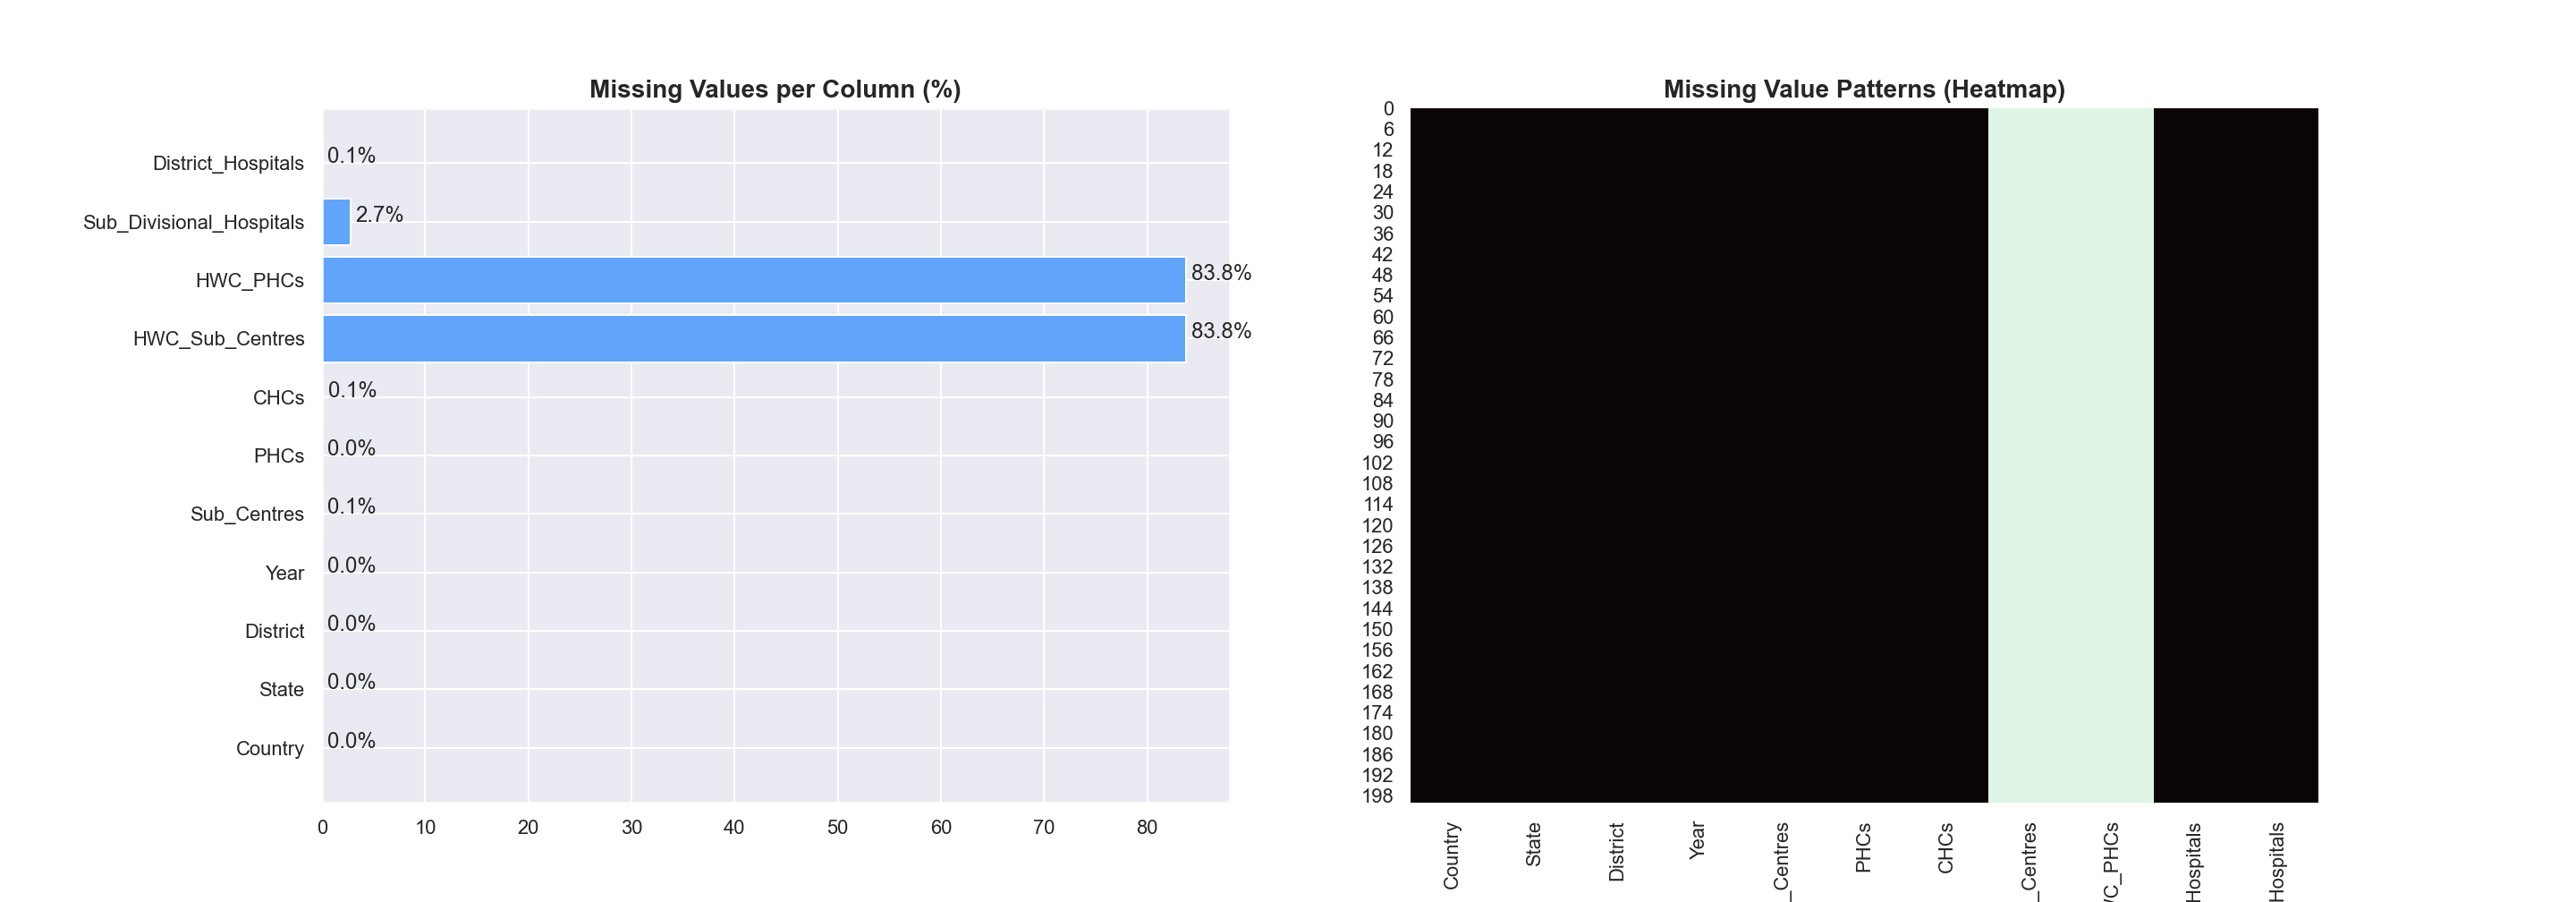

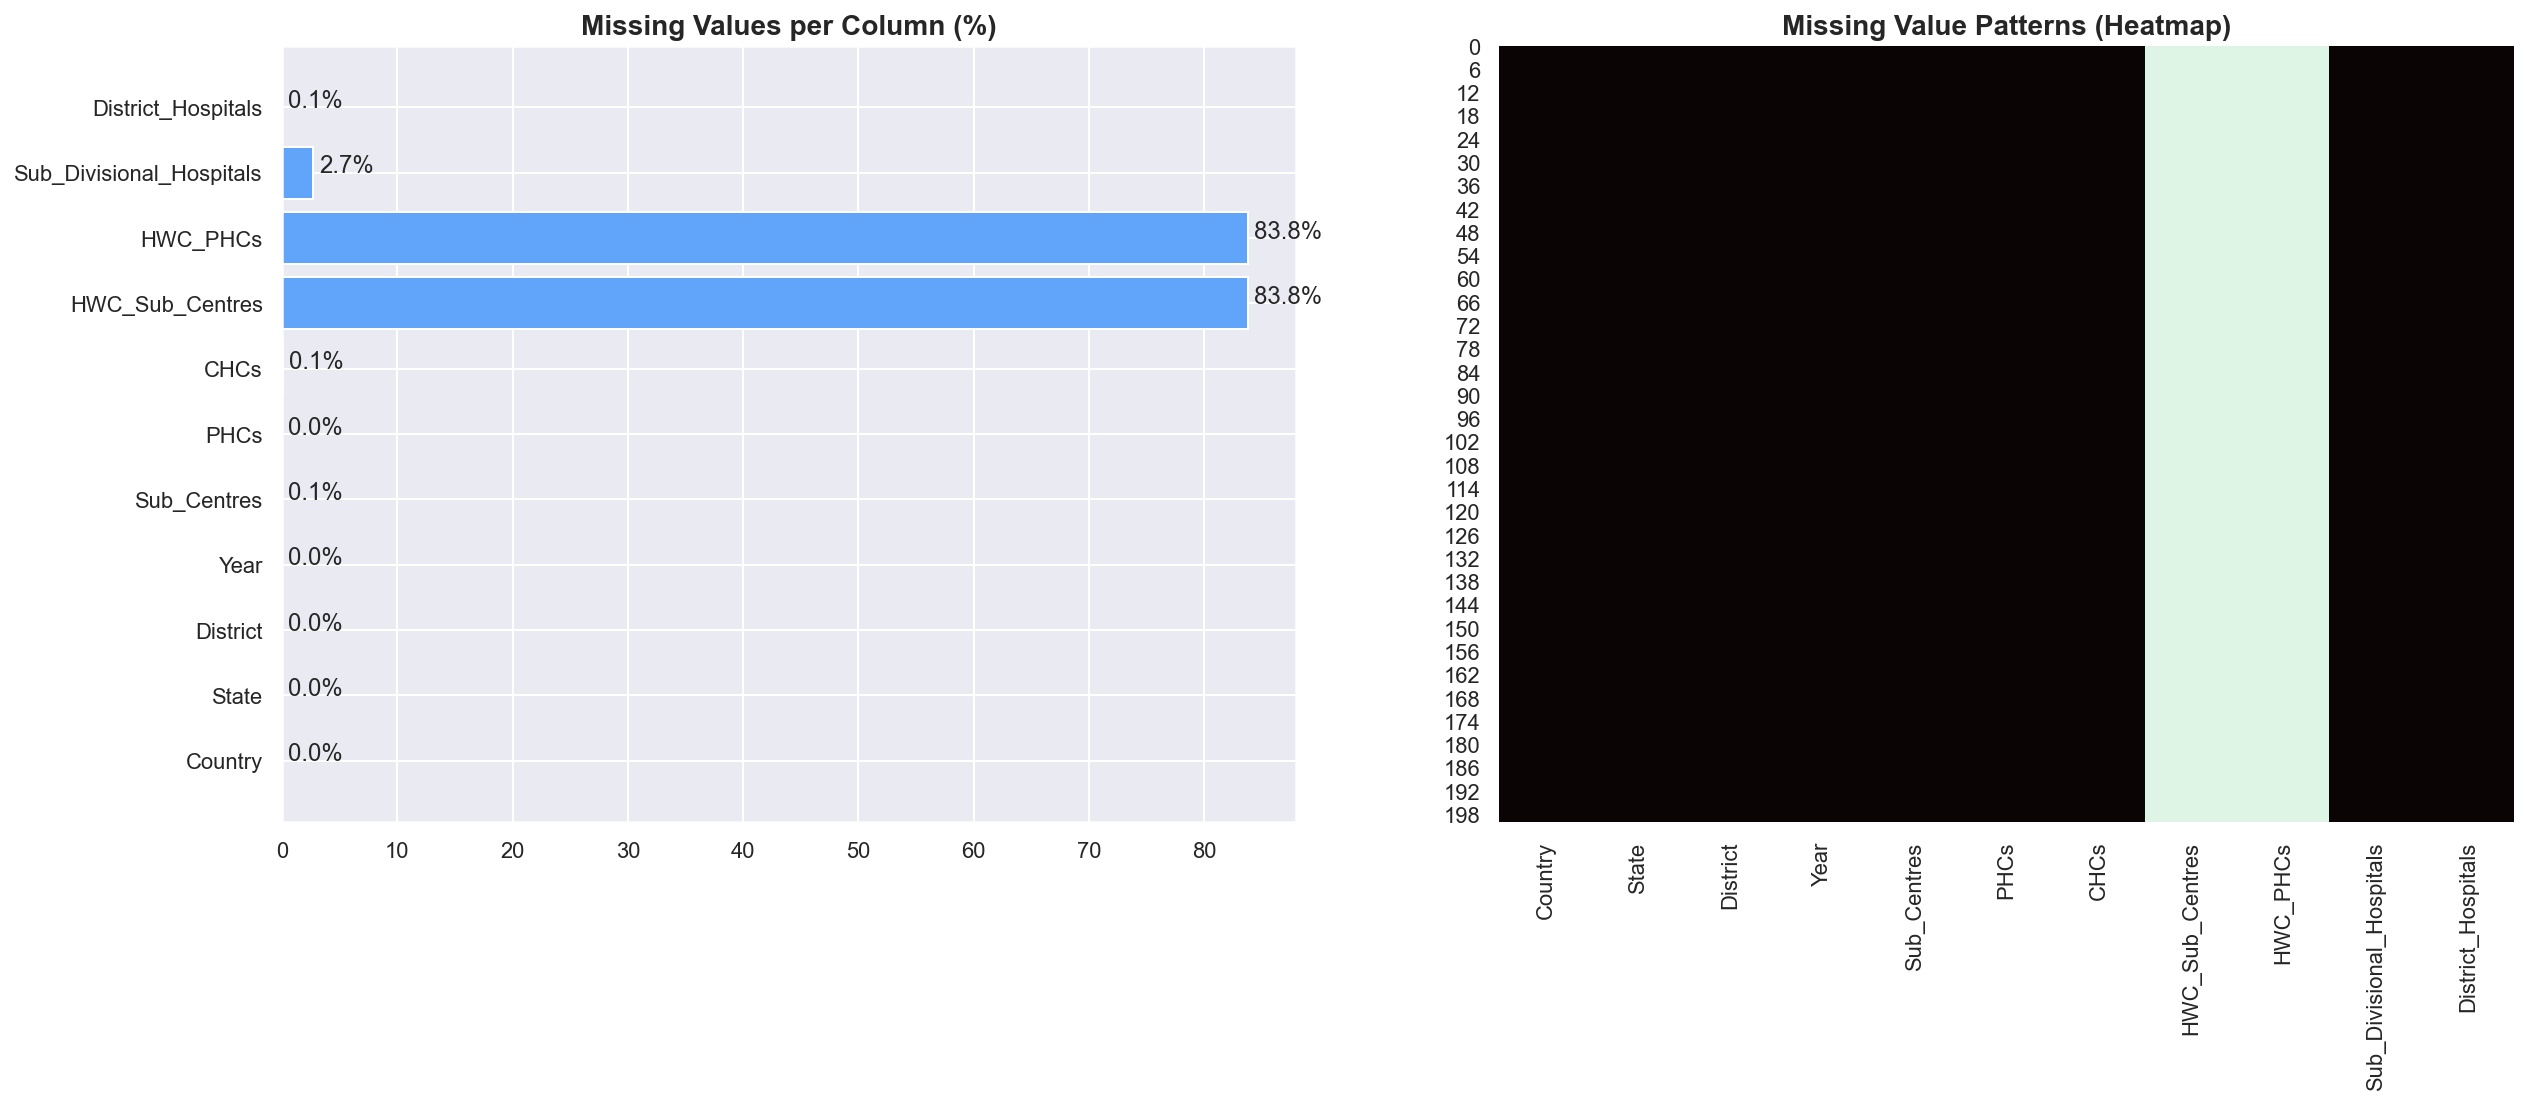

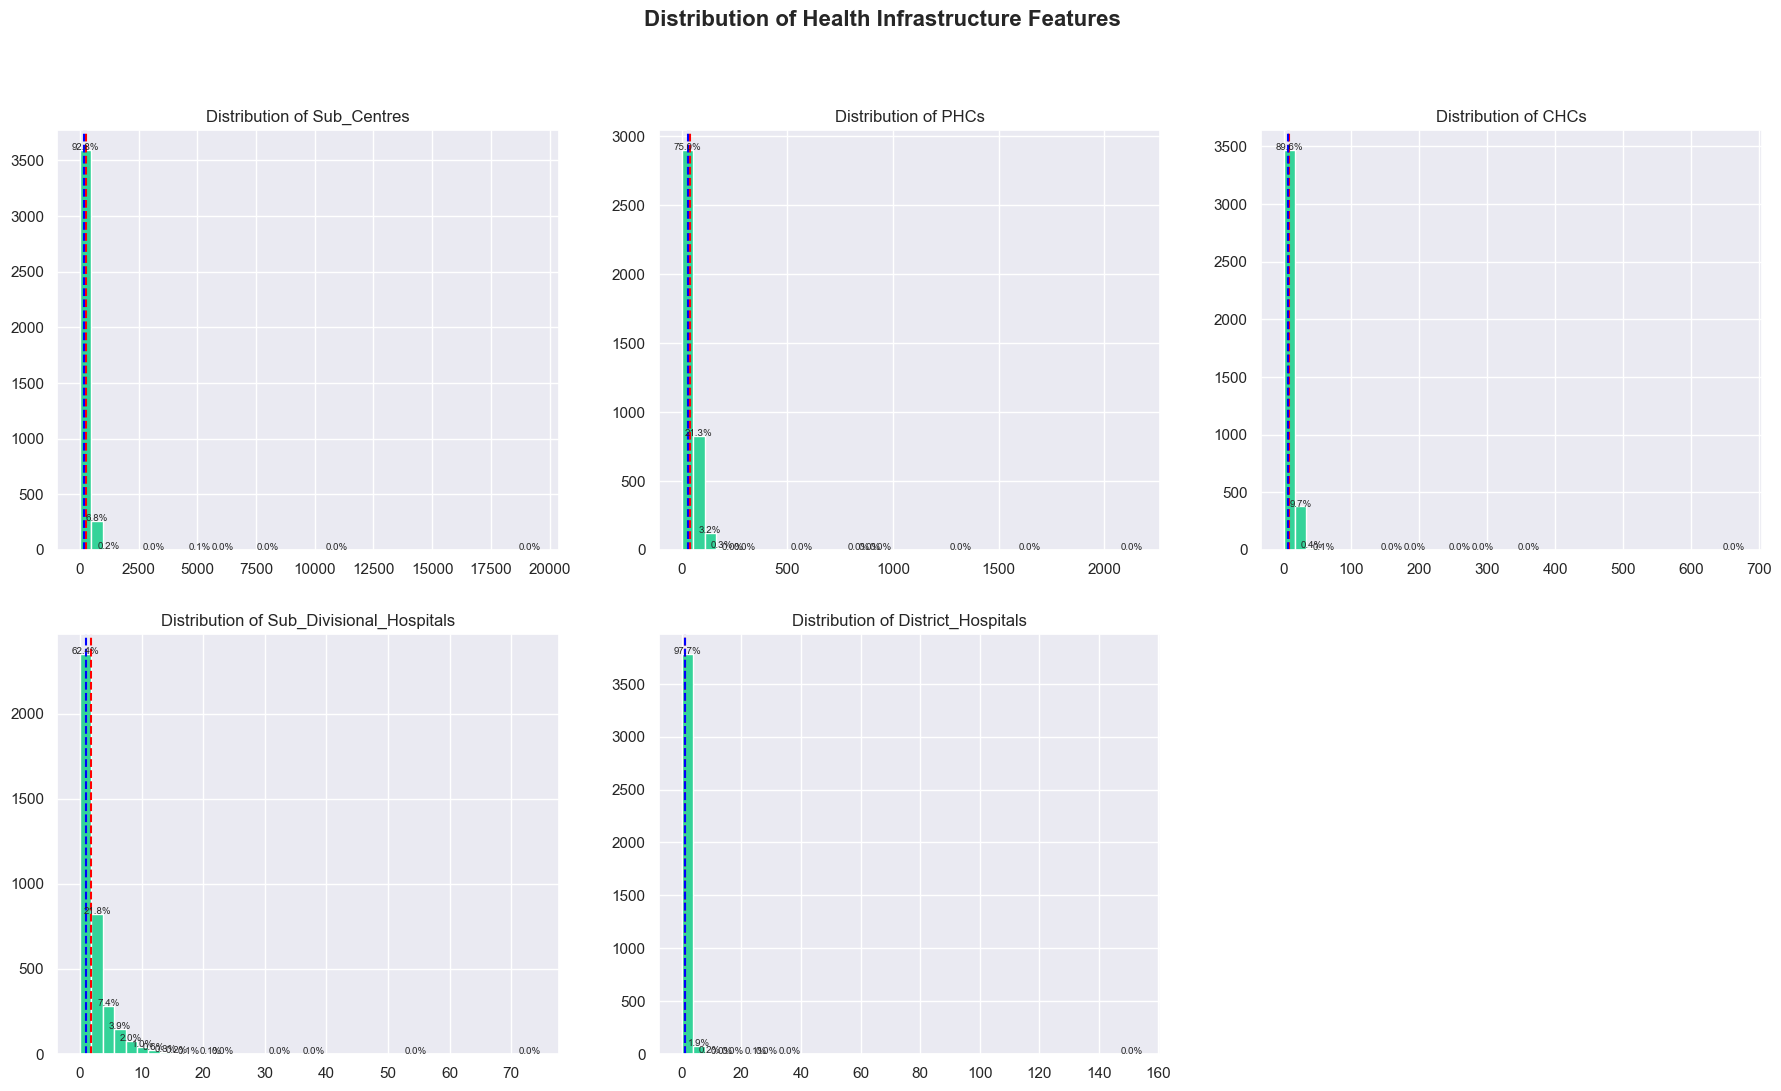

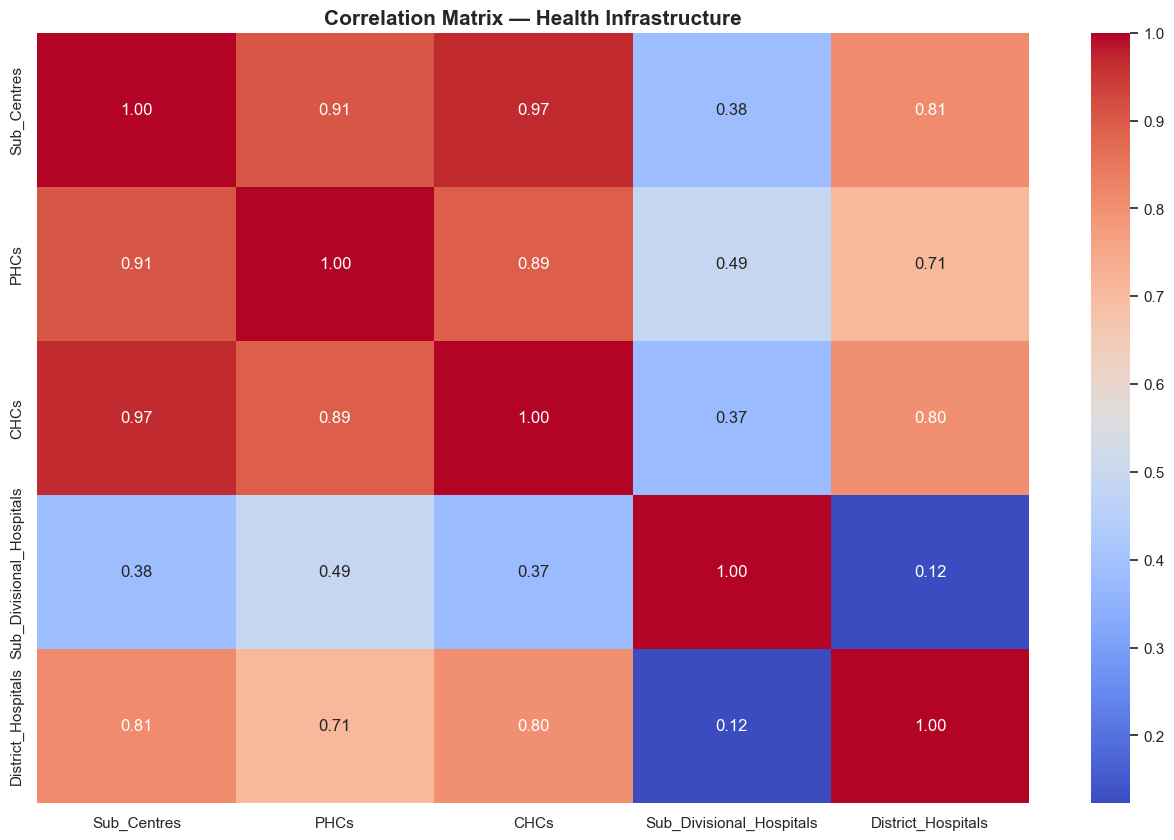

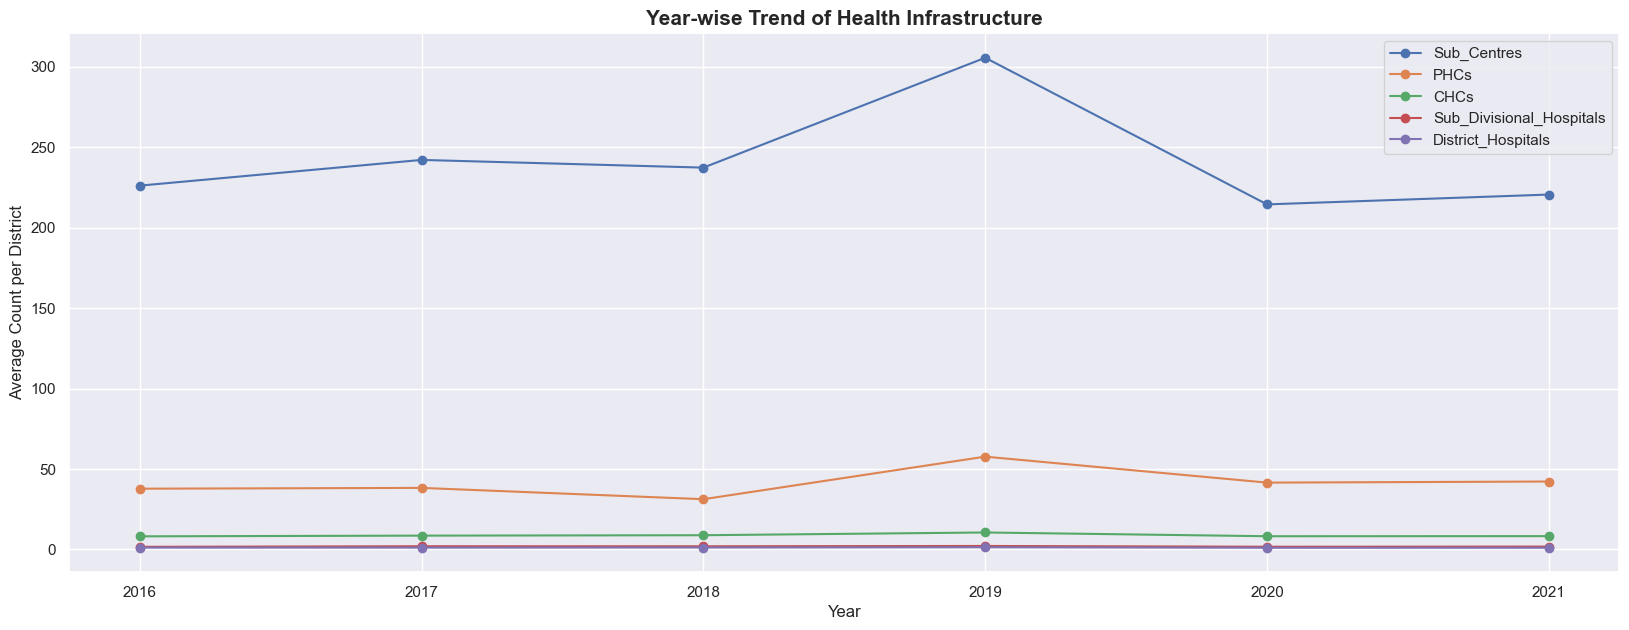

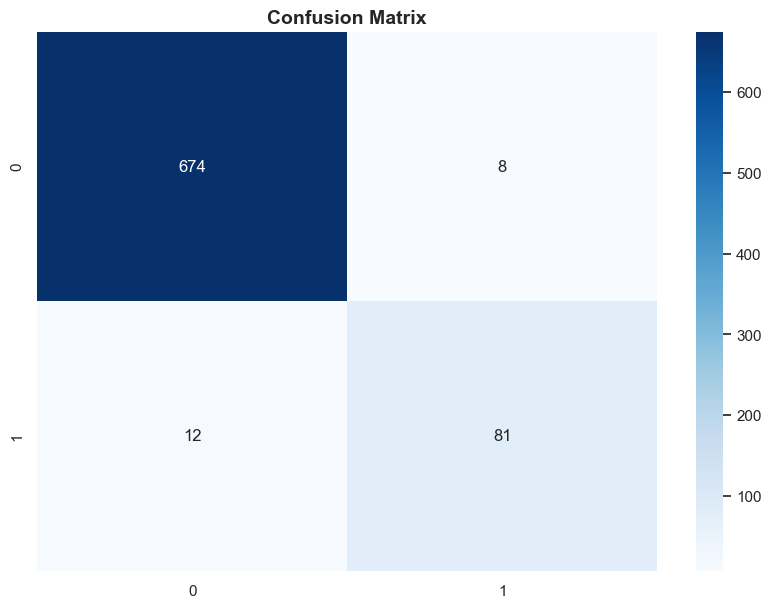

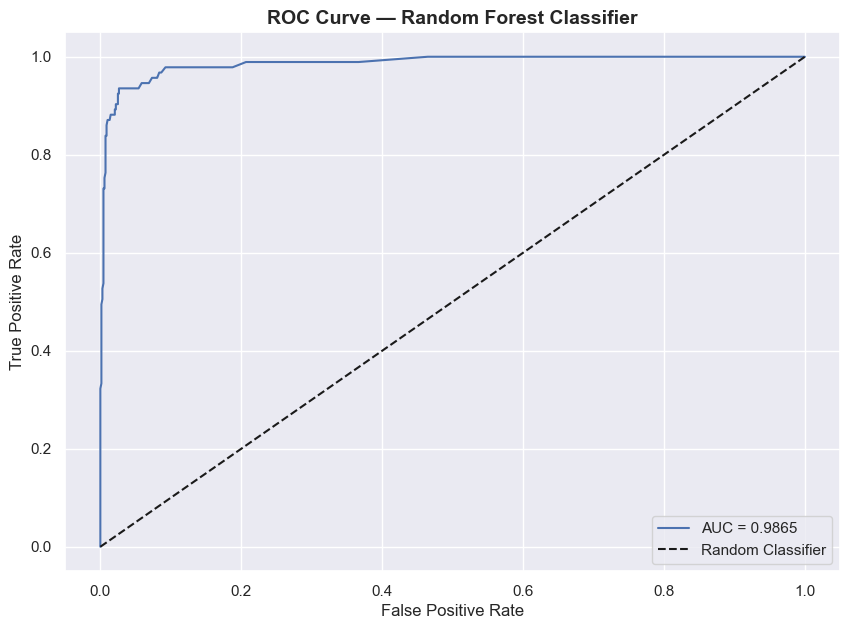

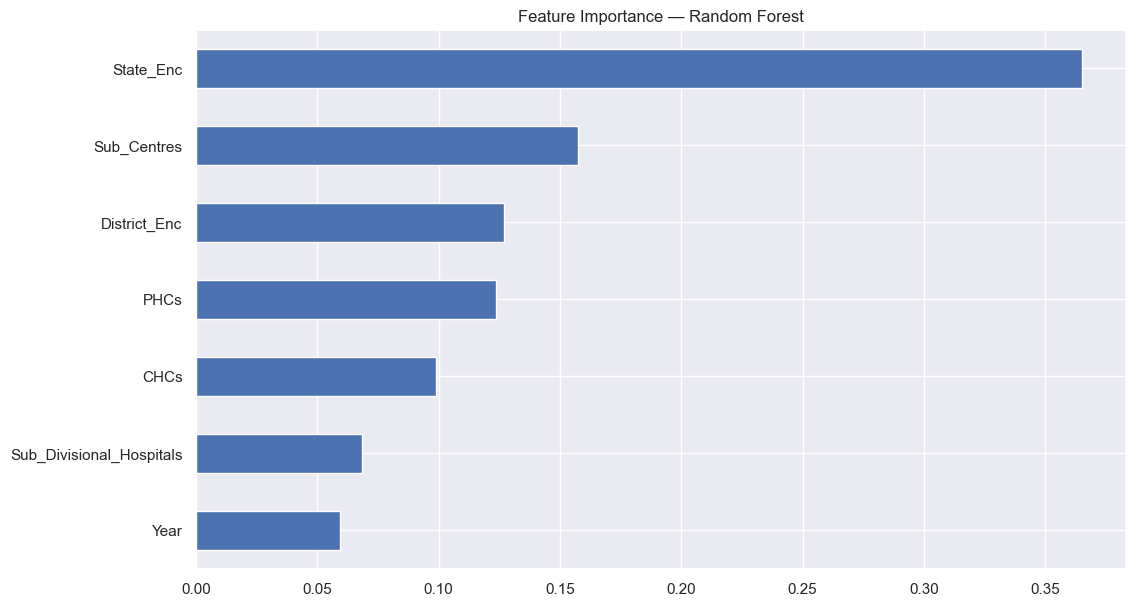

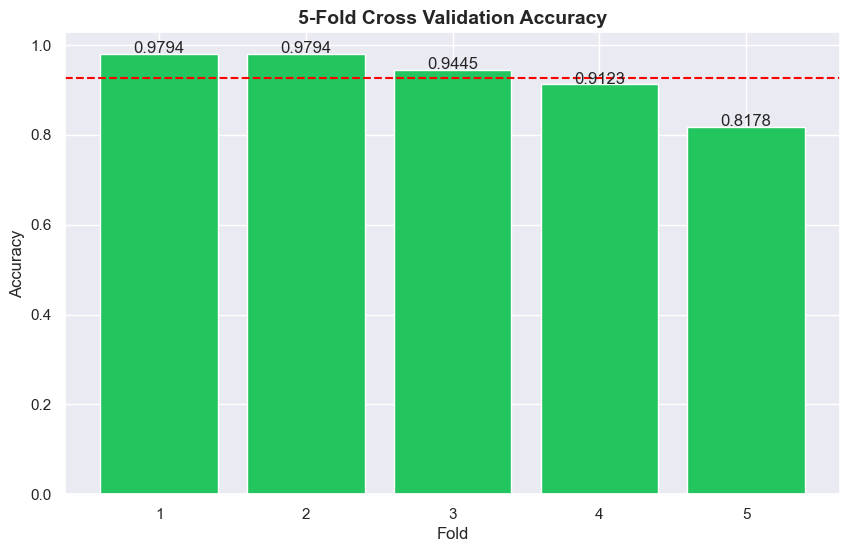

In [2]:
# ================================
# 📦 IMPORTS
# ================================
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import panel as pn

pn.extension(sizing_mode="stretch_width")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *

# ================================
# 🎨 STYLE (UNCHANGED + BUTTON FIX ONLY)
# ================================
plt.style.use("dark_background")
sns.set_theme(style="darkgrid")

pn.config.raw_css = ["""
body {
    background: radial-gradient(circle at top, #1e293b, #020617);
    font-family: 'Segoe UI';
    color: white;
}

.kpi {
    background: rgba(30,41,59,0.9);
    border-radius: 14px;
    padding: 20px;
    margin: 10px;
    text-align: center;
    color: white !important;
}

/* ===== BUTTON UI FIX (ONLY ADDITION) ===== */
.bk-btn-group .bk-btn {
    background-color: #1e293b !important;
    color: white !important;
    border-radius: 12px !important;
    margin-right: 10px;
    padding: 10px 18px;
    font-weight: 500;
}

.bk-btn-group .bk-btn.bk-active {
    background-color: #22c55e !important;
    color: black !important;
}

.bk-btn-group .bk-btn:hover {
    background-color: #334155 !important;
}
"""]

# ================================
# 📂 LOAD DATA
# ================================
df_raw = pd.read_csv('datasetpython.csv')

df_raw.columns = [
    'Country','State','District','Year',
    'Sub_Centres','PHCs','CHCs',
    'HWC_Sub_Centres','HWC_PHCs',
    'Sub_Divisional_Hospitals','District_Hospitals'
]

df_raw['Year'] = df_raw['Year'].str.extract(r'(\d{4})').astype(int)

num_cols = ['Sub_Centres','PHCs','CHCs','Sub_Divisional_Hospitals','District_Hospitals']

# ================================
# 📊 KPI
# ================================
kpi_row = pn.Row(
    pn.pane.Markdown(f"<div class='kpi'>📊<br>Total Rows<br><b>{len(df_raw)}</b></div>"),
    pn.pane.Markdown(f"<div class='kpi'>🗺️<br>States<br><b>{df_raw['State'].nunique()}</b></div>"),
    pn.pane.Markdown(f"<div class='kpi'>📍<br>Districts<br><b>{df_raw['District'].nunique()}</b></div>"),
    pn.pane.Markdown(f"<div class='kpi'>📅<br>Years<br><b>{df_raw['Year'].nunique()}</b></div>")
)

# ================================
# 📊 VISUALS
# ================================
fig_missing, axes = plt.subplots(1,2, figsize=(20,7))
missing_pct = df_raw.isnull().mean()*100
bars = axes[0].barh(missing_pct.index, missing_pct.values, color="#60a5fa")

for bar, val in zip(bars, missing_pct.values):
    axes[0].text(val + 0.5, bar.get_y()+bar.get_height()/2, f"{val:.1f}%")

sns.heatmap(df_raw.isnull().head(200), cmap="mako", cbar=False, ax=axes[1])
axes[0].set_title("Missing Values per Column (%)", fontsize=14, fontweight='bold')
axes[1].set_title("Missing Value Patterns (Heatmap)", fontsize=14, fontweight='bold')
# Distribution
fig_dist, axes = plt.subplots(2,3, figsize=(22,12))
axes = axes.flatten()

for i,col in enumerate(num_cols):
    data = df_raw[col].dropna()

    counts, bins, patches = axes[i].hist(data, bins=40, color="#34d399", edgecolor="white")

    axes[i].set_title(f"Distribution of {col}")

    mean = data.mean()
    median = data.median()

    axes[i].axvline(mean, color='red', linestyle='--')
    axes[i].axvline(median, color='blue', linestyle='--')

    total = sum(counts)
    for count, patch in zip(counts, patches):
        if count > 0:
            percent = (count / total) * 100
            axes[i].text(patch.get_x()+patch.get_width()/2,
                         patch.get_height(),
                         f"{percent:.1f}%",
                         ha='center', fontsize=7)

axes[-1].axis('off')
fig_dist.suptitle("Distribution of Health Infrastructure Features", fontsize=16, fontweight='bold')

# Correlation
fig_corr, ax = plt.subplots(figsize=(16,10))
sns.heatmap(df_raw[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation Matrix — Health Infrastructure", fontsize=15, fontweight='bold')
# Trend
yearly = df_raw.groupby('Year')[num_cols].mean()
fig_trend, ax = plt.subplots(figsize=(20,7))
for col in num_cols:
    ax.plot(yearly.index, yearly[col], marker='o', label=col)
ax.legend()
ax.set_title("Year-wise Trend of Health Infrastructure", fontsize=15, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Average Count per District")
# ================================
# 🧠 MODEL
# ================================
df = df_raw.copy()
df.drop(columns=['HWC_Sub_Centres','HWC_PHCs'], inplace=True)

df[num_cols] = SimpleImputer(strategy='median').fit_transform(df[num_cols])

df['State_Enc'] = LabelEncoder().fit_transform(df['State'])
df['District_Enc'] = LabelEncoder().fit_transform(df['District'])

X = df[['Sub_Centres','PHCs','CHCs','Sub_Divisional_Hospitals','Year','State_Enc','District_Enc']]
y = (df['District_Hospitals'] >= 2).astype(int)

X_scaled = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=200)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

# Confusion Matrix
fig_confusion, ax = plt.subplots(figsize=(10,7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues", ax=ax)
ax.set_title("Confusion Matrix", fontsize=14, fontweight='bold')
# ROC
fig_roc, ax = plt.subplots(figsize=(10,7))
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.4f}")
ax.plot([0,1],[0,1],'k--', label="Random Classifier")
ax.legend()
ax.set_title("ROC Curve — Random Forest Classifier", fontsize=14, fontweight='bold')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
# Feature Importance
fig_feature, ax = plt.subplots(figsize=(12,7))
pd.Series(rf.feature_importances_, index=X.columns).sort_values().plot.barh(ax=ax)
ax.set_title("Feature Importance — Random Forest")

# Cross Validation
cv_scores = cross_val_score(rf, X_scaled, y, cv=5)

fig_cv, ax = plt.subplots(figsize=(10,6))
bars = ax.bar(range(1,6), cv_scores, color="#22c55e")

mean_cv = cv_scores.mean()
ax.axhline(mean_cv, color='red', linestyle='--')

for bar, val in zip(bars, cv_scores):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.002, f"{val:.4f}", ha='center')
ax.set_title("5-Fold Cross Validation Accuracy", fontsize=14, fontweight='bold')
ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
# ================================
# 🎛 BUTTON
# ================================
# ================================
# 🎛 BUTTON (ONLY ICONS ADDED)
# ================================
section = pn.widgets.RadioButtonGroup(
    options=[
        "📊 Overview",
        "📈 Trend",
        "🔥 Heatmap",
        "📊 Distribution",
        "🤖 Model"
    ],
    value="📊 Overview"
)

def show(sec):
    if sec == "📊 Overview":
        return pn.pane.Matplotlib(fig_missing)
    elif sec == "📈 Trend":
        return pn.pane.Matplotlib(fig_trend)
    elif sec == "🔥 Heatmap":
        return pn.pane.Matplotlib(fig_corr)
    elif sec == "📊 Distribution":
        return pn.pane.Matplotlib(fig_dist)
    elif sec == "🤖 Model":
        return pn.Column(
            pn.Row(pn.pane.Matplotlib(fig_confusion),
                   pn.pane.Matplotlib(fig_roc)),
            pn.Row(pn.pane.Matplotlib(fig_feature),
                   pn.pane.Matplotlib(fig_cv))
        )

dynamic_view = pn.bind(show, section)

template = pn.template.FastListTemplate(
    title="🏥 Health Infrastructure Dashboard",
    main=[kpi_row, section, dynamic_view],
    header_background="#020617"
)

template.show()
template.servable()